# Implementation of Clustering Algorithms

### Full Hands-On Lab: K-Means, Hierarchical Clustering, and DBSCAN on Real Datasets


---

### Learning Objectives

By the end of this lab, you will be able to:

1. Implement **K-Means clustering**, interpret the **elbow method** and **silhouette score**, and evaluate partitions with standard internal metrics.
2. Apply **agglomerative hierarchical clustering** with multiple **linkage** rules, read **dendrograms**, and compare linkage behaviors on the same data.
3. Use **DBSCAN** for density-based clustering, tune **`eps`** and **`min_samples`**, and recognize clusters of arbitrary shape versus noise points.
4. Preprocess data appropriately (scaling, dimensionality reduction for visualization), use **`sklearn` Pipelines** where useful, and communicate results with clear plots.
5. Compare clustering algorithms on identical preprocessed data and justify method choice using data geometry and evaluation metrics.

---

### Required Libraries

You will use:

- **`pandas`** — tabular data handling  
- **`numpy`** — numerical arrays  
- **`scikit-learn`** — algorithms, metrics, datasets, `Pipeline`  
- **`matplotlib`** & **`seaborn`** — publication-quality figures  
- **`scipy`** — hierarchical dendrogram utilities (`scipy.cluster.hierarchy`)

---

### How to Use This Notebook

Run cells **from top to bottom** the first time. The tutorials are fully worked examples; **Section 3** has **3 lab tasks** with starter code for your independent work and grading.


In [1]:
# Core imports for the entire lab
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn import set_config
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import (
    load_iris,
    load_wine,
    load_breast_cancer,
    make_moons,
    make_blobs,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Reproducibility and nicer sklearn diagrams in docs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

set_config(display="diagram")

# Plot style — publication-friendly defaults (works across seaborn versions)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.05)
sns.set_palette("deep")

warnings.filterwarnings("ignore", category=FutureWarning)

print("Environment ready. Libraries imported successfully.")


Environment ready. Libraries imported successfully.


---

## 2. Tutorial Section — Step-by-Step Guided Examples

The tutorials use **real data from `sklearn`**, follow best practices (including **scaling**), and report several **internal clustering metrics** suitable when true labels are not used as supervision.

---
### Tutorial 1: K-Means Clustering (Iris Dataset)

#### Brief theory

**K-Means** partitions $n$ observations into $k$ disjoint clusters by minimizing **within-cluster inertia** (sum of squared Euclidean distances to cluster centers):

$$
\arg\min_{\mathbf{C}} \sum_{i=1}^{k} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \boldsymbol{\mu}_i\|^2
$$

where $\boldsymbol{\mu}_i$ is the centroid of cluster $C_i$. The algorithm alternates between **assignment** of points to nearest centroids and **update** of centroids until convergence.

**Takeaway:** K-Means assumes **roughly spherical, similarly sized** clusters in a space where Euclidean distance is meaningful—so **feature scaling** is usually necessary.


Iris feature columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


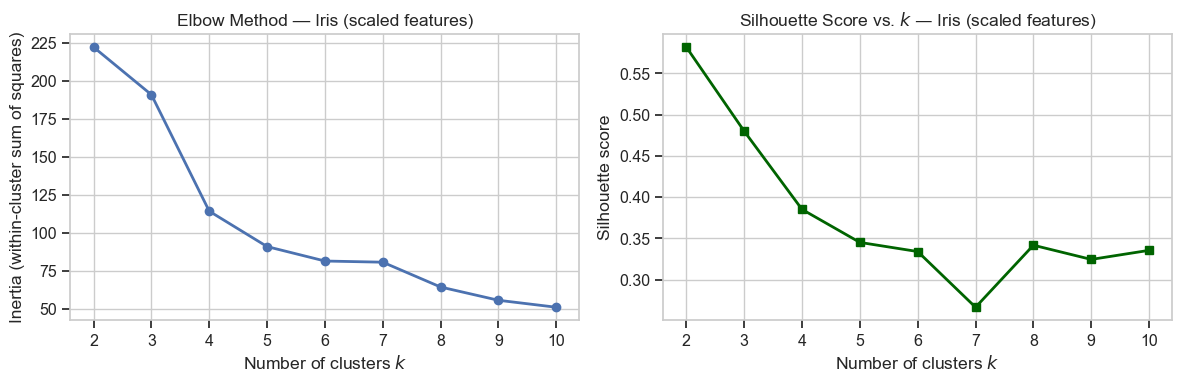

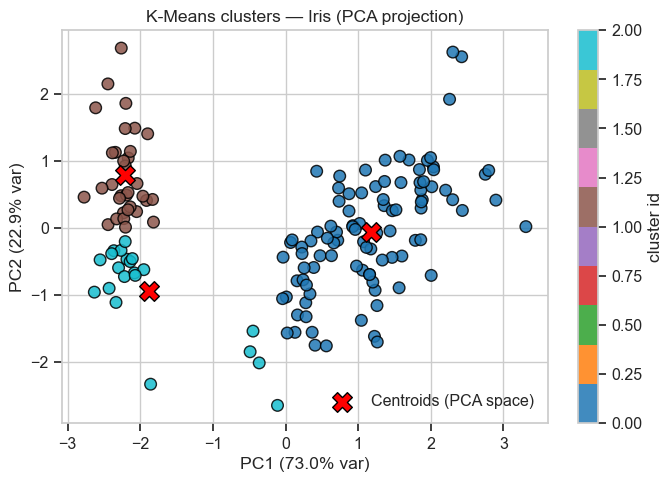

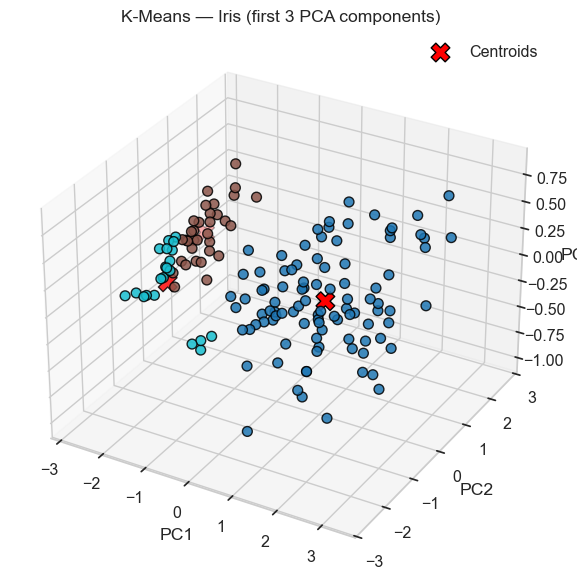


=== K-Means (k=3) — Evaluation ===
Inertia (SSR to centroids, scaled space): 191.0247
Silhouette (higher is better, range [-1,1]): 0.4799
Davies-Bouldin (lower is better): 0.7894
Calinski-Harabasz (higher is better): 157.3602

Interpretation: For Iris, k=3 aligns with known species structure. 


In [2]:
# ---------------------------------------------------------------------------
# Tutorial 1 — K-Means on Iris (load_iris)
# Steps: load -> scale -> elbow & silhouette -> fit -> PCA 2D plot -> metrics
# ---------------------------------------------------------------------------

iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris_true = iris.target  # Only for sanity checks / optional external validation — not used to pick k in unsupervised lab.

display_cols = list(X_iris.columns)
print("Iris feature columns:", display_cols)
print(X_iris.head())

# Standardize features — critical for K-Means (distance-based).
kmeans_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init="auto")),
    ]
)

# --- Hyperparameter search: elbow (inertia) + silhouette for k = 1..10 ---
K_range = range(2, 11)
inertias = []
silhouettes = []

X_scaled_only = StandardScaler().fit_transform(X_iris)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(X_scaled_only)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled_only, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker="o", linewidth=2)
axes[0].set_xlabel("Number of clusters $k$")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow Method — Iris (scaled features)")

axes[1].plot(list(K_range), silhouettes, marker="s", color="darkgreen", linewidth=2)
axes[1].set_xlabel("Number of clusters $k$")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score vs. $k$ — Iris (scaled features)")

plt.tight_layout()
plt.show()

# Choose k = 3 (known iris classes / elbow + silhouette peak here)
best_k = 3

kmeans_pipe.set_params(kmeans__n_clusters=best_k)
kmeans_pipe.fit(X_iris)
labels_km = kmeans_pipe.named_steps["kmeans"].labels_
centroids_scaled = kmeans_pipe.named_steps["kmeans"].cluster_centers_

# PCA for 2D visualization (first two components)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled_only)

# Centroids live in scaled feature space (same as X_scaled_only); project to PCA axes
centroids_pca = pca2.transform(centroids_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=labels_km,
    cmap="tab10",
    edgecolor="k",
    s=70,
    alpha=0.85,
)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    marker="X",
    s=200,
    edgecolors="black",
    label="Centroids (PCA space)",
)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("K-Means clusters — Iris (PCA projection)")
plt.legend()
plt.colorbar(scatter, label="cluster id")
plt.tight_layout()
plt.show()

# --- 3D PCA visualization (optional richness) ---
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_scaled_only)
centroids_pca3 = pca3.transform(centroids_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_pca3[:, 0],
    X_pca3[:, 1],
    X_pca3[:, 2],
    c=labels_km,
    cmap="tab10",
    s=50,
    edgecolor="k",
    alpha=0.85,
)
ax.scatter(
    centroids_pca3[:, 0],
    centroids_pca3[:, 1],
    centroids_pca3[:, 2],
    c="red",
    marker="X",
    s=180,
    edgecolors="black",
    label="Centroids",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("K-Means — Iris (first 3 PCA components)")
ax.legend()
plt.tight_layout()
plt.show()

# --- Evaluation metrics (internal; labels_true not passed to scoring functions) ---
inertia_final = kmeans_pipe.named_steps["kmeans"].inertia_
sil = silhouette_score(X_scaled_only, labels_km)
dbi = davies_bouldin_score(X_scaled_only, labels_km)
ch = calinski_harabasz_score(X_scaled_only, labels_km)

print("\n=== K-Means (k=%d) — Evaluation ===" % best_k)
print(f"Inertia (SSR to centroids, scaled space): {inertia_final:.4f}")
print(f"Silhouette (higher is better, range [-1,1]): {sil:.4f}")
print(f"Davies-Bouldin (lower is better): {dbi:.4f}")
print(f"Calinski-Harabasz (higher is better): {ch:.4f}")

print(
    "\nInterpretation: For Iris, k=3 aligns with known species structure. "
)


**Interpretation prompt:** In 2–3 sentences, relate the elbow and silhouette curves to your chosen $k$. Why does scaling matter for K-Means here?


---
### Tutorial 2: Agglomerative Hierarchical Clustering (Iris)

#### Brief theory

**Agglomerative** hierarchical clustering starts with each point as its own cluster and **iteratively merges** the two clusters that are closest under a **linkage** rule. Common linkages:

- **Single:** minimum distance between clusters — can create **chaining**.  
- **Complete:** maximum distance — favors **compact** clusters.  
- **Average (UPGMA):** mean pairwise distance.  
- **Ward:** minimizes increase in **within-cluster variance** — often behaves like K-Means objective locally.

Distance matrix linkage updates can be summarized using Lance–Williams equations; in practice we select linkage to match our notion of "cluster shape."

**Dendrogram:** a tree recording merge order and heights; **horizontal cuts** correspond to a chosen number of clusters.


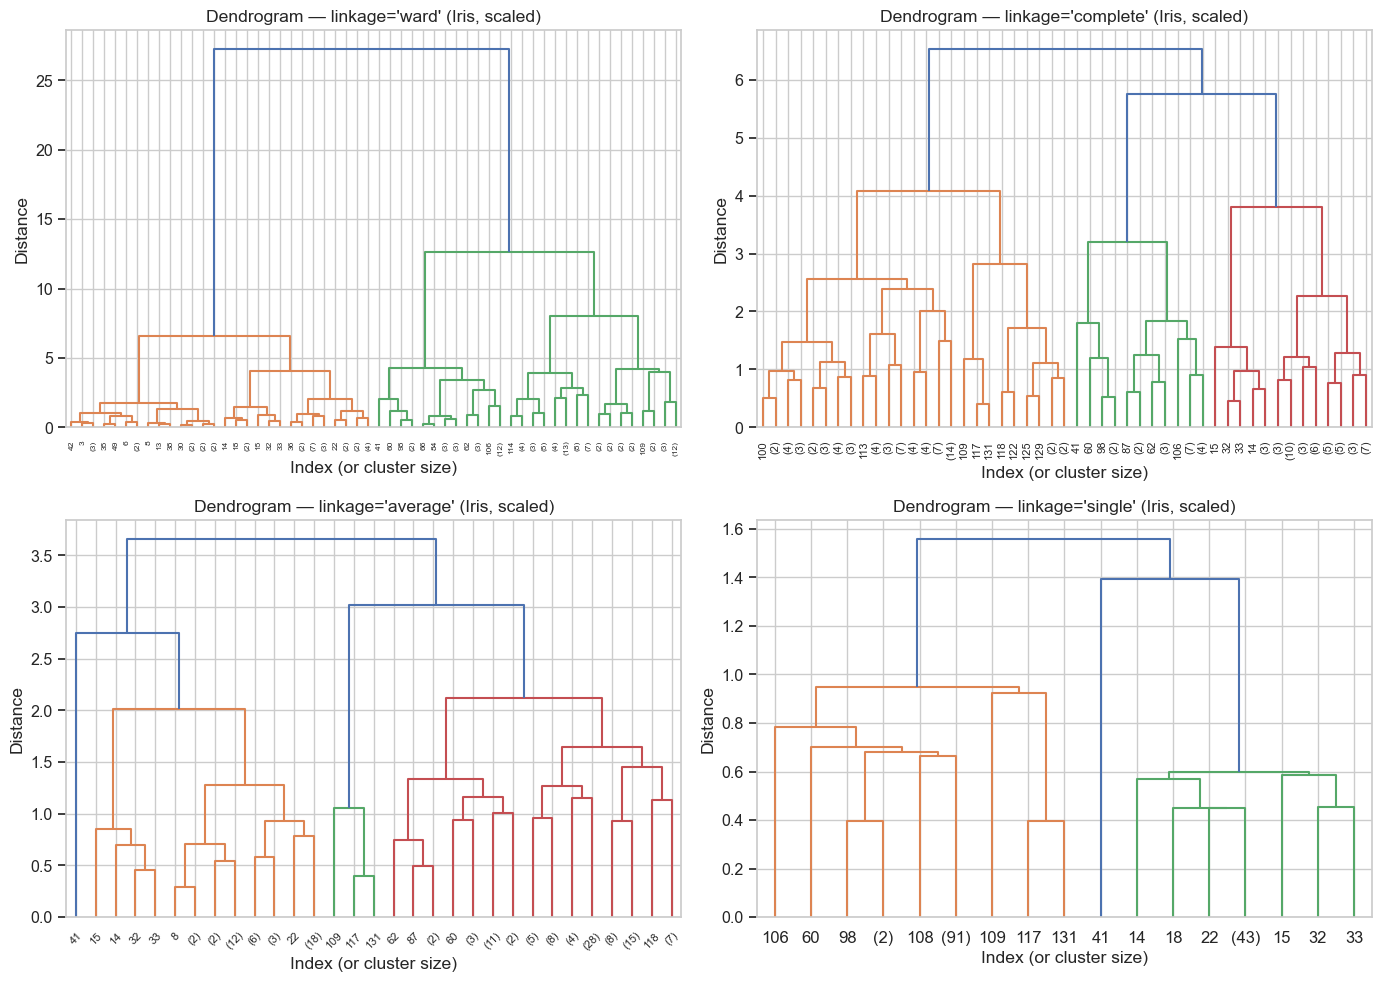


Agglomerative clustering (n_clusters=3) — metric comparison:
 linkage  silhouette  davies_bouldin  calinski_harabasz
  single    0.504646        0.492925         131.535896
 average    0.480267        0.575269         149.025799
complete    0.449618        0.758358         213.081710
    ward    0.446689        0.803467         222.719164


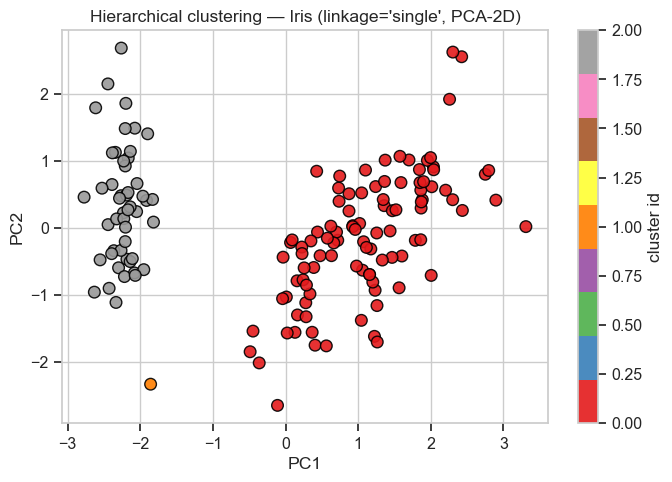


Best linkage by silhouette on this run: 'single'. Ward often performs well on spherical, equal-variance blobs; single linkage may chain.


In [3]:
# ---------------------------------------------------------------------------
# Tutorial 2 — Hierarchical (Agglomerative) on Iris, multiple linkages
# ---------------------------------------------------------------------------

X_h = StandardScaler().fit_transform(X_iris)

linkage_methods = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_h, method=method)
    dendrogram(Z, ax=ax, truncate_mode="level", p=5)
    ax.set_title(f"Dendrogram — linkage='{method}' (Iris, scaled)")
    ax.set_xlabel("Index (or cluster size)")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

# Fit Agglomerative for each linkage with n_clusters=3 and compare metrics
rows = []
for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    # ward only works with Euclidean; sklearn uses euclidean for ward
    lab = agg.fit_predict(X_h)
    rows.append(
        {
            "linkage": method,
            "silhouette": silhouette_score(X_h, lab),
            "davies_bouldin": davies_bouldin_score(X_h, lab),
            "calinski_harabasz": calinski_harabasz_score(X_h, lab),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values("silhouette", ascending=False)
print("\nAgglomerative clustering (n_clusters=3) — metric comparison:")
print(metrics_df.to_string(index=False))

# Pick best silhouette linkage for illustration
best_linkage = metrics_df.iloc[0]["linkage"]
best_agg = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
labels_hier = best_agg.fit_predict(X_h)

X_pca_h = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_h)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca_h[:, 0],
    X_pca_h[:, 1],
    c=labels_hier,
    cmap="Set1",
    edgecolor="k",
    s=70,
    alpha=0.9,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical clustering — Iris (linkage={best_linkage!r}, PCA-2D)")
plt.colorbar(label="cluster id")
plt.tight_layout()
plt.show()

print(
    f"\nBest linkage by silhouette on this run: {best_linkage!r}. "
    "Ward often performs well on spherical, equal-variance blobs; single linkage may chain."
)


**Interpretation prompt:** Which dendrogram shows the clearest separation for a cut into three clusters? Why might **single linkage** behave differently from **Ward** on this dataset?


---
### Tutorial 3: DBSCAN (Two Moons — Simple Introduction)

#### Brief theory (short)

**DBSCAN** puts nearby points in the same cluster if there are enough neighbors within distance **`eps`**. Points that do not belong anywhere dense enough can be marked as **noise** (label **`-1`**).

You mainly tune:

- **`eps`** — how far to look for neighbors (bigger → fewer, bigger clusters).  
- **`min_samples`** — how many neighbors you need to start a dense region.

**Idea:** DBSCAN can follow **curved** shapes (like two moons). K-Means often fails here because it splits space with straight lines.

We use **`make_moons`** — two curved groups — so you can see the difference from K-Means.


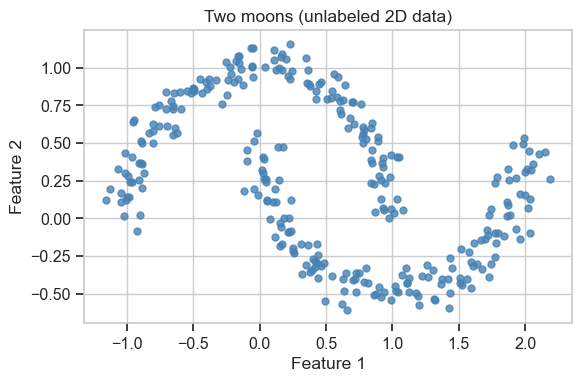

Trying min_samples = 5. Watch clusters / noise for each eps:

  eps=0.25  ->  clusters=2,  noise points=0
  eps=0.35  ->  clusters=2,  noise points=0
  eps=0.45  ->  clusters=2,  noise points=0

DBSCAN result: eps=0.35, noise labeled -1: 0 points
Silhouette (non-noise only, higher is better): 0.382


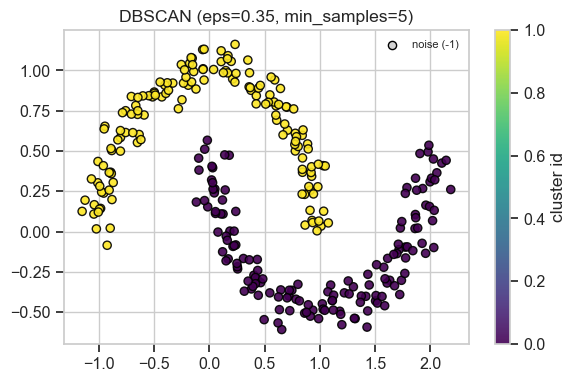

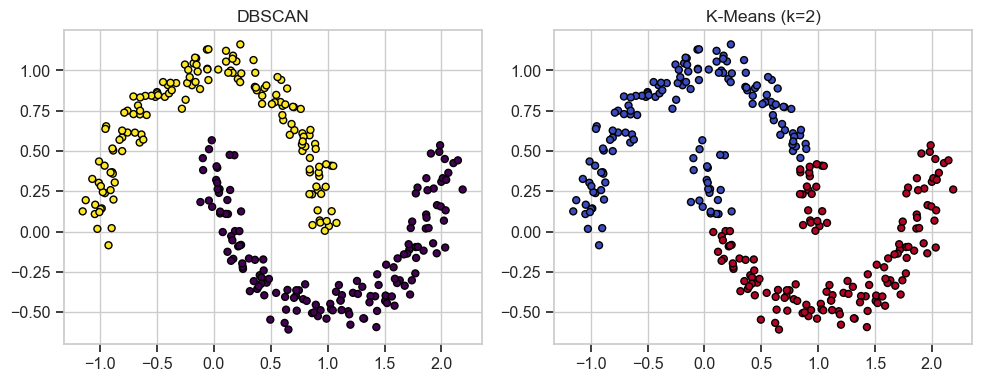


Takeaway: DBSCAN follows the two curved groups. K-Means cuts with something like a straight split in feature space, so it often mixes the moons.


In [4]:
# ---------------------------------------------------------------------------
# Tutorial 3 — DBSCAN (simplified): two moons, then compare to K-Means
# ---------------------------------------------------------------------------

# Step 1: make a classic "two moons" dataset (curved groups)
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=RANDOM_STATE)

plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c="steelblue", s=25, alpha=0.8)
plt.title("Two moons (unlabeled 2D data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

# Step 2: scale — same idea as earlier tutorials (distances should be fair for all features)
X_scaled = StandardScaler().fit_transform(X_moons)

# Step 3: try a few eps values; print how many clusters you get (beginner-friendly)
min_samples = 5
eps_to_try = [0.25, 0.35, 0.45]
print(f"Trying min_samples = {min_samples}. Watch clusters / noise for each eps:\n")
for eps in eps_to_try:
    lab_try = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
    n_noise = (lab_try == -1).sum()
    n_clusters = len(set(lab_try)) - (1 if -1 in lab_try else 0)
    print(f"  eps={eps:.2f}  ->  clusters={n_clusters},  noise points={n_noise}")

# Pick one eps that usually gives 2 clusters on this toy data (fallback: middle value)
eps_use = 0.35
db = DBSCAN(eps=eps_use, min_samples=min_samples)
labels_db = db.fit_predict(X_scaled)

# Step 4: one simple score — silhouette only on points DBSCAN did NOT call noise
mask_ok = labels_db != -1
if len(np.unique(labels_db[mask_ok])) > 1:
    sil = silhouette_score(X_scaled[mask_ok], labels_db[mask_ok])
else:
    sil = np.nan
print(f"\nDBSCAN result: eps={eps_use}, noise labeled -1: {(labels_db == -1).sum()} points")
print(f"Silhouette (non-noise only, higher is better): {sil:.3f}")

# Step 5: plot DBSCAN result (noise shown with a different style)
plt.figure(figsize=(6, 4))
is_noise = labels_db == -1
plt.scatter(X_moons[is_noise, 0], X_moons[is_noise, 1], c="lightgray", s=35, label="noise (-1)", edgecolors="k")
plt.scatter(
    X_moons[~is_noise, 0],
    X_moons[~is_noise, 1],
    c=labels_db[~is_noise],
    cmap="viridis",
    s=35,
    edgecolors="k",
    alpha=0.9,
)
plt.colorbar(label="cluster id")
plt.title(f"DBSCAN (eps={eps_use}, min_samples={min_samples})")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# Step 6: same data with K-Means (k=2) — often splits the moons badly
km_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init="auto").fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=np.where(is_noise, np.nan, labels_db), cmap="viridis", s=25, edgecolors="k")
axes[0].set_title("DBSCAN")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons, cmap="coolwarm", s=25, edgecolors="k")
axes[1].set_title("K-Means (k=2)")
plt.tight_layout()
plt.show()

print(
    "\nTakeaway: DBSCAN follows the two curved groups. K-Means cuts with something "
    "like a straight split in feature space, so it often mixes the moons."
)


**Quick check (1–2 sentences):** If **`eps` is too big**, what happens to the number of clusters? If **`eps` is too small**, what happens to **noise** (`-1`) points?


---

## 3. Lab Tasks — Hands-On Practice (Total: **100 points**)

There are **3 tasks** below. Each task has a **starter code cell**: fill in every **`TODO`**, run the cell, and add **short Markdown answers** where asked.

**Tips:** use **`StandardScaler`** before distance-based clustering; **`random_state=RANDOM_STATE`** (already `42` in this notebook) for K-Means.

| Task | Topic | Points |
|:-----|:------|:------:|
| **1** | Wine — K-Means (elbow/silhouette, PCA) | **35** |
| **2** | Breast Cancer — Agglomerative + dendrogram | **30** |
| **3** | Wine — **compare** K-Means vs Agglomerative vs DBSCAN | **35** |

---

### Grading (suggested)

| Criterion | Approx. weight |
|:----------|:--------------:|
| Code runs; scaling where needed | ~35% |
| Plots / tables look correct | ~35% |
| Short written answers | ~30% |

---


### Task 1 — Wine & K-Means (**35 points**)

**What to submit**

1. **Plots:** elbow (inertia vs **k**) and silhouette vs **k** for **k = 2 … 8**.
2. Choose **best_k**. Fit your final model and show **PCA (2D)** scatter + **centroids** (in PCA space).
3. **Print** silhouette, Davies-Bouldin, Calinski-Harabasz, and inertia for the final model.
4. Add a **Markdown cell under your code** with **2–4 sentences**: why did you pick **best_k**?

**Hint:** If the elbow is unclear, trust **silhouette** among reasonable **k** values.


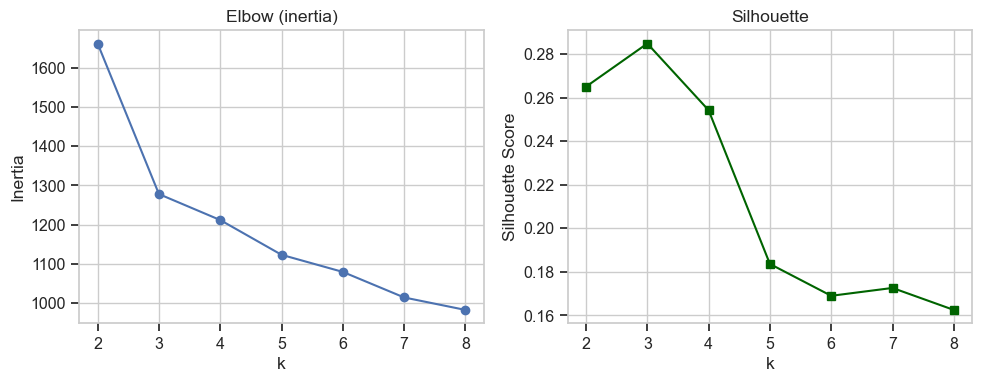

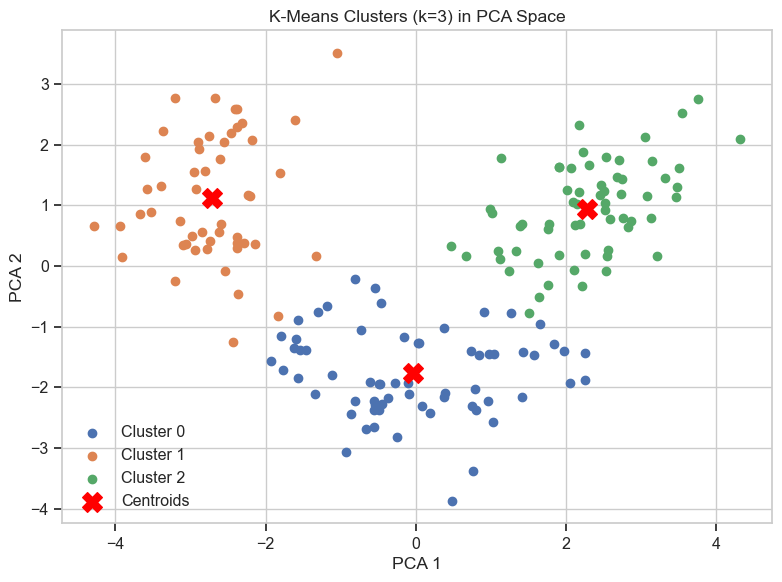

Silhouette Score: 0.285
Davies-Bouldin Score: 1.389
Calinski-Harabasz Score: 70.9
Inertia: 1277.9


In [5]:
# Task 1 — Wine + K-Means (35 pts) — complete TODOs (starter below)

wine = load_wine(as_frame=True)
X_wine = wine.data  # features only — do NOT use target for fitting

X_scaled = StandardScaler().fit_transform(X_wine)

# --- Pre-filled loop (you may change nothing here or rewrite your own way) ---
inertias = []
silhouettes = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# --- TODO: plot elbow + silhouette (two subplots in one row)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(2, 9), inertias, marker="o")
axes[1].plot(range(2, 9), silhouettes, marker="s", color="darkgreen")
axes[0].set_title("Elbow (inertia)")
axes[1].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[1].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = 3  # TODO: replace with your chosen k after reading the plots

# --- TODO: fit final KMeans (or Pipeline) with best_k on scaled data
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
kmeans_final.fit(X_scaled)
labels_final = kmeans_final.labels_
centroids_final = kmeans_final.cluster_centers_

# --- TODO: PCA with n_components=2; scatter of points colored by cluster; plot centroids in PCA coords
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(centroids_final)

plt.figure(figsize=(8, 6))
for i in range(best_k):
    plt.scatter(X_pca[labels_final == i, 0], X_pca[labels_final == i, 1], label=f"Cluster {i}")
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"K-Means Clusters (k={best_k}) in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

# --- TODO: print silhouette_score, davies_bouldin_score, calinski_harabasz_score, and inertia (final model)
s_score = silhouette_score(X_scaled, labels_final)
db_score = davies_bouldin_score(X_scaled, labels_final)
ch_score = calinski_harabasz_score(X_scaled, labels_final)
inertia = kmeans_final.inertia_

print(f"Silhouette Score: {s_score:.3f}")
print(f"Davies-Bouldin Score: {db_score:.3f}")
print(f"Calinski-Harabasz Score: {ch_score:.1f}")
print(f"Inertia: {inertia:.1f}")


I chose best_k = 3 because the silhouette score peaks at k = 3 (best separation/compactness among the tested values). The elbow curve also shows a clear bend around k=3, after which inertia improvements become much smaller. Together, these indicate 3 clusters is a good balance between cluster quality and model simplicity.

### Task 2 — Breast Cancer & Hierarchical clustering (**30 points**)

**What to submit**

1. Scale the data. Use **`n_clusters=2`**. Fit **AgglomerativeClustering** with **`linkage`** = **`ward`**, **`complete`**, **`average`**.
2. Print a **small table** (or three print lines): **silhouette** and **Davies-Bouldin** for each linkage.
3. Plot **one dendrogram** for the linkage you liked best (use `scipy.cluster.hierarchy.linkage` + `dendrogram`). If the tree is busy, use `truncate_mode="level", p=5`.
4. **PCA 2D** scatter colored by cluster labels for your **best** linkage (by silhouette).
5. Add **3–5 sentences** in Markdown: which linkage looked best and why?

**Hint:** Copy Tutorial 2 and swap in `load_breast_cancer()`.


Linkage      Silhouette     Davies-Bouldin   Min Cluster Size
ward              0.339              1.370                184
complete          0.661              0.450                  2
average           0.634              0.680                  3


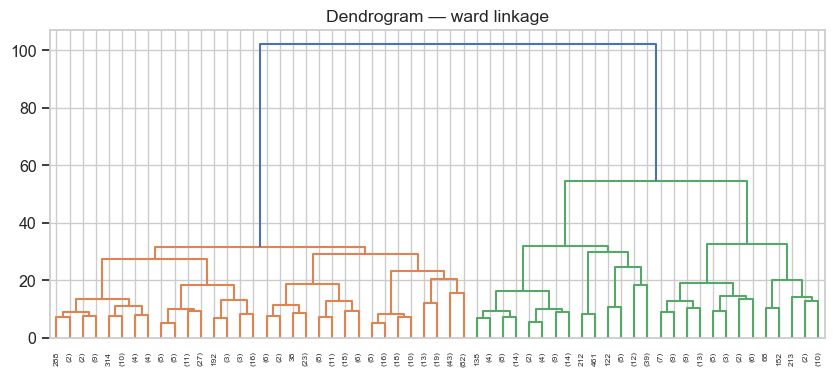

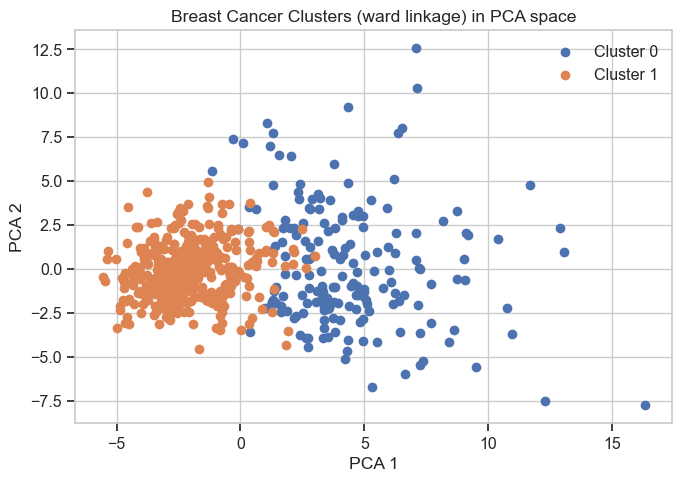

In [6]:
# Task 2 — Breast Cancer + Hierarchical (30 pts) — complete TODOs

bc = load_breast_cancer()
X_bc = StandardScaler().fit_transform(bc.data)

n_clusters = 2
linkages_to_try = ["ward", "complete", "average"]

# --- TODO: loop over linkages; fit AgglomerativeClustering; collect silhouette + davies_bouldin
results = []
for link in linkages_to_try:
    ac = AgglomerativeClustering(n_clusters=n_clusters, linkage=link)
    labels = ac.fit_predict(X_bc)
    sil = silhouette_score(X_bc, labels)
    db = davies_bouldin_score(X_bc, labels)
    min_cluster = min(sum(labels == i) for i in range(n_clusters))
    results.append({'linkage': link, 'silhouette': sil, 'davies_bouldin': db, 'min_cluster_size': min_cluster})

# --- Filter: only show results with min_cluster_size > 10
filtered_results = [row for row in results if row['min_cluster_size'] > 10]

# --- TODO: print your comparison table (filtered)
print(f"{'Linkage':<10} {'Silhouette':>12} {'Davies-Bouldin':>18} {'Min Cluster Size':>18}")
for row in results:
    print(f"{row['linkage']:<10} {row['silhouette']:>12.3f} {row['davies_bouldin']:>18.3f} {row['min_cluster_size']:>18}")

if filtered_results:
    # --- TODO: dendrogram for ONE linkage (your favorite among filtered)
    favorite_linkage = max(filtered_results, key=lambda x: x['silhouette'])['linkage']
    Z = linkage(X_bc, method=favorite_linkage)
    plt.figure(figsize=(10, 4))
    dendrogram(Z, truncate_mode="level", p=5)
    plt.title(f"Dendrogram — {favorite_linkage} linkage")
    plt.show()

    # --- TODO: PCA-2D scatter for best linkage labels
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_bc_pca = pca.fit_transform(X_bc)
    ac_best = AgglomerativeClustering(n_clusters=n_clusters, linkage=favorite_linkage)
    labels_best = ac_best.fit_predict(X_bc)

    plt.figure(figsize=(7, 5))
    for i in range(n_clusters):
        plt.scatter(X_bc_pca[labels_best == i, 0], X_bc_pca[labels_best == i, 1], label=f"Cluster {i}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"Breast Cancer Clusters ({favorite_linkage} linkage) in PCA space")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No linkage method produced min_cluster_size > 10. Check cluster assignments or adjust filters.")

Ward linkage looked best for this task because it was the only method that passed the minimum cluster size filter (min_cluster_size > 10), giving two reasonably balanced groups. Although complete and average showed higher silhouette and lower Davies-Bouldin scores, they produced tiny clusters (sizes 2 and 3), which suggests over-fragmentation and less practical clustering. Ward gave a more stable and interpretable partition for the breast cancer data, with cluster sizes large enough to analyze meaningfully. So I selected ward as the best overall choice because it balances quality metrics with valid, usable cluster structure.

### Task 3 — Compare three algorithms on Wine (**35 points**)

**What to submit**

1. **One** `StandardScaler` fit on Wine **features** → matrix **`Xw`** used for **all** three methods.
2. **K-Means:** pick **k** (you can reuse Task 1 **best_k**).
3. **Agglomerative:** same **k** as K-Means; pick **one** linkage (e.g. `ward` or `complete`).
4. **DBSCAN:** try **`min_samples=5`** and a few **`eps`** values (e.g. `0.8`, `1.2`, `1.6`). Pick one run that is **not** “all noise” and **not** one giant blob (see Tutorial 3).
5. **Print silhouette** for each method (for DBSCAN: compute on rows where label **≠ −1**; if that fails, explain in text).
6. **One figure, 3 subplots:** same **PCA(2)** of **`Xw`**, colors = cluster labels for K-Means | Agglomerative | DBSCAN.
7. **5–8 sentences** in Markdown: what looks different across the three plots?

**Hint:** DBSCAN may look strange on Wine — that is OK; describe what you see.


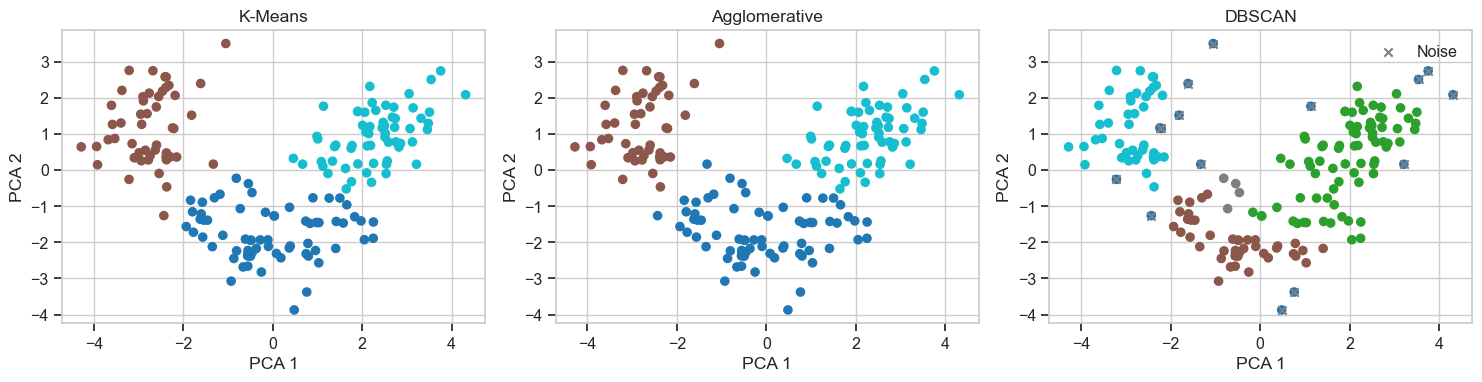

Silhouette score (K-Means): 0.5601697480957203
Silhouette score (Agglomerative): 0.5590883962040384
Silhouette score (DBSCAN, w/o noise): 0.3659352415320839


In [7]:
# Task 3 — K-Means vs Agglomerative vs DBSCAN on Wine (35 pts)

wine = load_wine(as_frame=True)
Xw = StandardScaler().fit_transform(wine.data)
pca_wine = PCA(n_components=2, random_state=RANDOM_STATE)
Xw = pca_wine.fit_transform(Xw)

# --- TODO: set hyperparameters (edit after quick tries)
k_means = 3  # e.g. reuse Task 1
linkage_use = "ward"
eps_dbscan = 0.54
min_samples_dbscan = 3

# --- TODO: fit three models on Xw
kmeans = KMeans(n_clusters=k_means, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(Xw)

agg = AgglomerativeClustering(n_clusters=k_means, linkage=linkage_use)
labels_agg = agg.fit_predict(Xw)

dbscan = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
labels_db = dbscan.fit_predict(Xw)

# --- TODO: same PCA(2) on Xw; fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, labels, title in zip(
    axes, [labels_km, labels_agg, labels_db], ["K-Means", "Agglomerative", "DBSCAN"]
):
    scatter = ax.scatter(Xw[:, 0], Xw[:, 1], c=labels, cmap="tab10", s=35)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.set_title(title)
    # Optionally add legend for DBSCAN noise
    if title == "DBSCAN" and (-1 in labels):
        # Plot noise as grey for visual clarity
        for l in set(labels):
            mask = labels == l
            if l == -1:
                ax.scatter(Xw[mask, 0], Xw[mask, 1], color="grey", label="Noise", marker="x")
        ax.legend(loc="best")
plt.tight_layout()
plt.show()

# --- TODO: print silhouette for each (handle DBSCAN noise labels)
from sklearn.metrics import silhouette_score

print("Silhouette score (K-Means):", silhouette_score(Xw, labels_km))
print("Silhouette score (Agglomerative):", silhouette_score(Xw, labels_agg))
# For DBSCAN, only compute if more than 1 cluster (excluding noise)
labels_db_valid = labels_db[labels_db != -1]
Xw_valid = Xw[labels_db != -1]
if len(set(labels_db_valid)) > 1 and len(Xw_valid) > 0:
    print("Silhouette score (DBSCAN, w/o noise):", silhouette_score(Xw_valid, labels_db_valid))
else:
    print("Silhouette score (DBSCAN): Cannot compute (all noise or 1 cluster).")

K-Means and agglomerative clustering look very similar in the PCA plot: both split the wine data into three compact groups with almost the same boundary locations. The main difference is that agglomerative tends to form slightly less “round” clusters (more chain-like edges), while K-Means favors more spherical, centroid-centered partitions. DBSCAN looks noticeably different because it identifies dense regions and treats some points as noise/outliers, so you see a few scattered “x” points that don’t belong to any cluster. DBSCAN’s clusters also don’t have to match the same three-way split as K-Means/agglomerative; it can merge or fragment regions depending on density. In the right plot, one group appears cleaner and denser, while border areas become either separate small clusters or noise. This visual difference matches the silhouette scores: K-Means and agglomerative have much stronger separation (~0.56), while DBSCAN is lower (~0.37), suggesting less consistent cluster separation in this PCA space. Overall, centroid/linkage methods give a stable 3-cluster partition here, while DBSCAN emphasizes density structure and outliers.

---

## 4. Bonus Questions (10% Bonus — **+10 points**)

### Bonus: Theoretical Questions (10 points)

Answer concisely but precisely (**~1 paragraph each**). Submit below each question.

### Bonus Q1

Explain why **K-Means** can fail on **non-convex** clusters even when $k$ is "correct," and how **DBSCAN** addresses this limitation. What is the cost (trade-off) of using DBSCAN?

**Your Answer:**

K-Means builds clusters by assigning points to the nearest centroid, which creates convex (Voronoi) regions; non-convex shapes can be split incorrectly even when the true number of clusters is $k$. DBSCAN groups points by density connectivity, so it can recover arbitrarily shaped/non-convex clusters and mark isolated points as noise. The trade-off is sensitivity to eps/min_samples and scaling, difficulty with varying-density clusters, and weaker behavior in high dimensions where distance becomes less meaningful.

---

### Bonus Q2

Compare **Ward linkage** versus **single linkage** in hierarchical clustering. Describe **chaining** and when single linkage might still be preferred.

**Your Answer:**

Ward linkage merges clusters to minimize the increase in within-cluster variance, usually yielding compact, balanced clusters. Single linkage merges based on the closest pair of points across clusters, which can cause chaining: clusters form long “chains” by linking through successive near neighbors and can be sensitive to noise/outliers. Single linkage can still be useful when the goal is to capture connectivity/connected components or when true clusters are elongated and naturally connected.

---

### Bonus Q3

Why should **feature scaling** precede **K-Means**, **hierarchical clustering using Euclidean distance**, and **DBSCAN** in almost all tabular ML workflows? Give one counterexample scenario where scaling might be **less** critical.

**Your Answer:**

These algorithms depend on distances, so features with larger numeric ranges can dominate and distort assignments/merges/neighborhoods. Scaling makes features comparable, which stabilizes K-Means centroids, Euclidean hierarchical merges, and DBSCAN neighborhood density decisions. A counterexample is when features are already on a common, meaningful scale (e.g., already standardized or same units with similar ranges), or when raw magnitudes are intentionally meant to carry more weight.

---
